isotropic mean field solution

In [134]:
import matplotlib.pyplot as plt
import numpy as np
import slave_rotor_atomic
import slave_rotor_MF

In [135]:
pars = {'beta':20.,
        'U':10.,
        'alpha':1.,
        'eps_0':0.,
        'mixing':0.1,
        't_perp':None,
        'K_init':0.25,
        'iterations':100,
        'M_trunc':20,
        }

In [154]:
def solver(pars):
    Ks = []
    hs = []
    U = pars['U']
    alpha = pars['alpha']
    dens = pars['denisty']
    M_trunc = pars['M_trunc']
    t_perp = pars['t_perp']
    iterations = pars['iterations']
    beta = pars['beta']
    mixing = pars['mixing']
    precomp =  slave_rotor_atomic.build_rotor_precomp(U, alpha, M_trunc)
    dos     = slave_rotor_MF._DOS_precomp(t_perp)
    Ks.append(pars['K_init'])
    converged = False
    for it in range(iterations):
        K = Ks[it]
        def eval_L_rot(h_):
            Out = slave_rotor_atomic.eval_rotor_obs(precomp, h_, K, beta, obs_indices=(0,), n_eigs= 20)
            L_AVG = Out['obs'][0]
            COSTHETA_AVG = Out['Q']
            #I,_ = slave_rotor_MF._spinon_integrals(dos,COSTHETA_AVG, eps_0 , h_, beta)
            return L_AVG - 6. * (dens - 0.5)
        def rhs_L(h_):
            return 0.
        h_win = min( 10, max(2.0, 3.0 / (beta if beta != 'inf' else 1.0)))
        sols_h = slave_rotor_atomic.solve_sc(eval_L_rot, rhs_L, beta, h_window=10., n_coarse = 20, tol = 1e-10, verbose=False)
        h = sols_h[0]['h']
        hs.append(h)
        #######################
        #create rotor observables for this 'optimal' h
        #######################
        Out = slave_rotor_atomic.eval_rotor_obs(precomp, h, K, beta, obs_indices=(0,), n_eigs= 20)
        COSTHETA_AVG = Out['Q']
        #1)solve for epsilon_0
        def eval_L_dens(eps_):
            return (slave_rotor_MF._spinon_integrals(dos,COSTHETA_AVG, eps_ , h, beta)[0] - dens)
        def rhs_dens(eps_):
            return 0.
        sols_eps = slave_rotor_atomic.solve_sc(eval_L_dens, rhs_dens, beta, h_window=10., n_coarse = 20, tol = 1e-10, verbose=False)
        eps = sols_eps[0]['h'] # solutions are still in key 'h'
        #2)get new K
        _,I = slave_rotor_MF._spinon_integrals(dos,COSTHETA_AVG, eps , h, beta)
        K_raw = 2.*6.*COSTHETA_AVG*I

        K_new = mixing*K + (1-mixing)*K_raw
        Ks.append(K_new)
        #
        #try:
        #    mu_eff = (h - eps_0) / (Out["Q"]**2)
        #except ZeroDivisionError:
        #    mu_eff = np.nan
        #print("mu_eff =", mu_eff)
        #
        if it == 0:
            print(f"  iter {it+1:3d}:  h={h:+.6f}   "
                  f"K={K:.6f}, K_new={K_new:.6f}")
            continue
        if it>0:
            delta = abs(Ks[-1] - Ks[-2]) + abs(hs[-1] - hs[-2])
            print(f"  iter {it+1:3d}:  h={h:+.6f}"
                  f"K={K:.6f}, K_new={K_new:.6f}  delta={delta:.2e}")
            if delta < 1e-10:
                converged = True
                break
    ##################
    #collect out info#
    ##################
    h_con = hs[-1]
    K_con = Ks[-1]
    rot_final = slave_rotor_atomic.eval_rotor_obs(precomp, h_con, K_con, beta, obs_indices=(0,1), n_eigs= 20)
    obs = rot_final['obs']
    #print('obs',obs)
    costh = rot_final['Q']
    I_n, _    = slave_rotor_MF._spinon_integrals(dos, costh, eps_0, h_con, beta)
    results = {
        'h': h_con, 'Q': costh, 'K': K_con,
        'L': obs[0], 'Lsq': obs[1],
        'n_spinon': I_n,
        'converged': converged,
        'iterations': it + 1,
        'hs':hs,
        'Ks':Ks,
    }
    return results


In [155]:
def solver(pars):
    Ks = []
    hs = []
    epss = []
    Qs = []
    Zs = []
    I0s = []
    I1s = []
    K_raws = []
    mus_eff = []
    iter_info = []

    U = pars['U']
    alpha = pars['alpha']

    # typo-safe
    dens = pars.get('density', pars.get('denisty'))

    N = pars.get('N', 6.0)
    M_trunc = pars['M_trunc']
    t_perp = pars['t_perp']
    iterations = pars['iterations']
    beta = pars['beta']
    mixing = pars['mixing']

    tol = pars.get('tol', 1e-10)
    h_window = pars.get('h_window', 10.0)
    eps_window = pars.get('eps_window', 10.0)
    n_coarse = pars.get('n_coarse', 51)
    n_eigs = pars.get('n_eigs', 20)

    verbose = pars.get('verbose', 1)

    #####################
    # STEP 0  Precompute#
    #####################
    precomp = slave_rotor_atomic.build_rotor_precomp(U, alpha, M_trunc)
    dos = slave_rotor_MF._DOS_precomp(t_perp)

    Ks.append(pars['K_init'])
    converged = False

    def pick_solution(sols, old=None):
        #NOTE fancier than just getting 'first' solution. Check its fine
        if verbose >1 : print(f'Solver found {len(sols)} solutions to SC equation..')
        if (verbose == 1) and (len(sols) != 1) : print(f'Solver found {len(sols)} solutions to SC equation..')
        if len(sols) == 0:
            raise RuntimeError("solve_sc returned no solutions")
        if old is None:
            # pick smallest residual if no previous solution exists
            return min(sols, key=lambda s: abs(s.get('F', np.inf)))
        # continue the closest branch
        return min(sols, key=lambda s: abs(s['h'] - old))

    def spinon_integrals(Q, eps_, h_):
        return slave_rotor_MF._spinon_integrals(dos, Q, eps_, h_, beta)

    def solve_h_eps_for_K(K, h_old=None, eps_old=None):
        # 1) solve h from fixed-density rotor constraint
        def eval_L_rot(h_):
            Out = slave_rotor_atomic.eval_rotor_obs(
                precomp, h_, K, beta,
                obs_indices=(0,),
                n_eigs=n_eigs
            )
            L_AVG = Out['obs'][0]
            return L_AVG - N * (dens - 0.5)

        def rhs_zero(x):
            return 0.0

        sols_h = slave_rotor_atomic.solve_sc(
            eval_L_rot,
            rhs_zero,
            beta,
            h_window=h_window,
            n_coarse=n_coarse,
            tol=tol,
            verbose=False
        )

        sol_h = pick_solution(sols_h, h_old)
        h = sol_h['h']

        # 2) rotor observables at this h,K
        Out = slave_rotor_atomic.eval_rotor_obs(
            precomp, h, K, beta,
            obs_indices=(0, 1),
            n_eigs=n_eigs
        )

        L_AVG = Out['obs'][0]
        L2_AVG = Out['obs'][1]
        Q = Out['Q']
        Z = Q**2

        # 3) solve epsilon_0 from density equation
        def eval_dens(eps_):
            I0, _ = spinon_integrals(Q, eps_, h)
            return I0 - dens

        sols_eps = slave_rotor_atomic.solve_sc(
            eval_dens,
            rhs_zero,
            beta,
            h_window=eps_window,
            n_coarse=n_coarse,
            tol=tol,
            verbose=False
        )

        sol_eps = pick_solution(sols_eps, eps_old)
        eps = sol_eps['h']   # solve_sc always uses key 'h'

        # 4) spinon integrals and K update
        I0, I1 = spinon_integrals(Q, eps, h)
        K_raw = 2.0 * N * Q * I1

        #NOTE this is not strictly true away from T=0, right?
        if abs(Z) > 1e-14:
            mu_eff = (h - eps) / Z
        else:
            mu_eff = np.nan

        info = {
            'K_in': K,
            'h': h,
            'eps': eps,
            'Q': Q,
            'Z': Z,
            'L': L_AVG,
            'Lsq': L2_AVG,
            'I0': I0,
            'I1': I1,
            'mu_eff': mu_eff,
            'K_raw': K_raw,
            'res_h': L_AVG - N * (dens - 0.5),
            'res_density': I0 - dens,
            'sol_h': sol_h,
            'sol_eps': sol_eps,
            'all_sols_h': sols_h,
            'all_sols_eps': sols_eps,
        }

        return info

    h_old = None
    eps_old = None

    for it in range(iterations):
        K = Ks[-1]

        #1) Solve for new h,epsilon_0,K_raw
        info = solve_h_eps_for_K(K, h_old=h_old, eps_old=eps_old)

        h = info['h']
        eps = info['eps']
        Q = info['Q']
        Z = info['Z']
        I0 = info['I0']
        I1 = info['I1']
        K_raw = info['K_raw']

        K_new = mixing * K + (1.0 - mixing) * K_raw

        info['iteration'] = it + 1
        info['K_new'] = K_new
        info['delta_K'] = abs(K_new - K)

        if it == 0:
            delta = np.inf
        else:
            delta = (
                abs(K_new - K)
                + abs(h - hs[-1])
                + abs(eps - epss[-1])
            )

        info['delta'] = delta

        hs.append(h)
        epss.append(eps)
        Qs.append(Q)
        Zs.append(Z)
        I0s.append(I0)
        I1s.append(I1)
        K_raws.append(K_raw)
        mus_eff.append(info['mu_eff'])
        iter_info.append(info)

        Ks.append(K_new)

        print(
            f"  iter {it+1:3d}: "
            f"h={h:+.8e} "
            f"eps={eps:+.8e} "
            f"K={K:+.8e} "
            f"K_raw={K_raw:+.8e} "
            f"K_new={K_new:+.8e} "
            f"Q={Q:+.8e} "
            f"I0={I0:+.8e} "
            f"I1={I1:+.8e} "
            f"mu_eff={info['mu_eff']:+.8e} "
            f"delta={delta:.3e}"
        )

        if delta < tol:
            converged = True
            break

        h_old = h
        eps_old = eps

    # Final consistency solve:
    # Ks[-1] is the final mixed K, so recompute h and eps for this K.
    K_con = Ks[-1]

    final_info = solve_h_eps_for_K(
        K_con,
        h_old=hs[-1] if len(hs) else None,
        eps_old=epss[-1] if len(epss) else None
    )

    h_con = final_info['h']
    eps_con = final_info['eps']
    costh = final_info['Q']
    Z_con = final_info['Z']

    results = {
        'h': h_con,
        'eps_0': eps_con,
        'Q': costh,
        'Z': Z_con,
        'K': K_con,
        'K_raw_final': final_info['K_raw'],
        'K_residual_final': K_con - final_info['K_raw'],

        'L': final_info['L'],
        'Lsq': final_info['Lsq'],
        'n_spinon': final_info['I0'],
        'I1': final_info['I1'],
        'mu_eff': final_info['mu_eff'],

        'res_h': final_info['res_h'],
        'res_density': final_info['res_density'],

        'converged': converged,
        'iterations': it + 1,

        'hs': hs,
        'epss': epss,
        'Ks': Ks,
        'Qs': Qs,
        'Zs': Zs,
        'I0s': I0s,
        'I1s': I1s,
        'K_raws': K_raws,
        'mus_eff': mus_eff,

        'iter_info': iter_info,
        'final_info': final_info,
    }

    return results

In [209]:
pars = {'beta':4000,
        'U':10.,
        'alpha':1.,
        'density':2./6,
        'mixing':0.1,
        't_perp':None,
        'K_init':2,
        'iterations':200,
        'M_trunc':8,
        'N':6,
        'tol':1e-8,
        'h_window':20.,
        'eps_window':20.,
        'n_coarse':51,
        'n_eigs':20,
        'verbose':1
        }
Us = np.linspace(5,5.5,num=10)
out = []
for U in Us:
        pars['U'] = U
        results = solver(pars)
        out.append(results['Z'])    


  iter   1: h=+5.00000000e+00 eps=+5.10250966e+00 K=+2.00000000e+00 K_raw=+1.47917396e+00 K_new=+1.53125656e+00 Q=-5.54414296e-01 I0=+3.33333334e-01 I1=-2.22332824e-01 mu_eff=-3.33500083e-01 delta=inf
  iter   2: h=+5.00000000e+00 eps=+5.07618551e+00 K=+1.53125656e+00 K_raw=+1.27518200e+00 K_new=+1.30078945e+00 Q=-4.77956313e-01 I0=+3.33333333e-01 I1=-2.22332384e-01 mu_eff=-3.33500083e-01 delta=2.568e-01
  iter   3: h=+5.00000000e+00 eps=+5.06158692e+00 K=+1.30078945e+00 K_raw=+1.14651362e+00 K_new=+1.16194120e+00 Q=-4.29730589e-01 I0=+3.33333333e-01 I1=-2.22331861e-01 mu_eff=-3.33500083e-01 delta=1.534e-01
  iter   4: h=+5.00000000e+00 eps=+5.05247103e+00 K=+1.16194120e+00 K_raw=+1.05826307e+00 K_new=+1.06863088e+00 Q=-3.96653967e-01 I0=+3.33333333e-01 I1=-2.22331293e-01 mu_eff=-3.33500083e-01 delta=1.024e-01
  iter   5: h=+5.00000000e+00 eps=+5.04630060e+00 K=+1.06863088e+00 K_raw=+9.94090704e-01 K_new=+1.00154472e+00 Q=-3.72602124e-01 I0=+3.33333333e-01 I1=-2.22330702e-01 mu_eff=-3.

In [213]:
pars = {'beta':'inf',
        'U':10.,
        'alpha':1.,
        'density':1./6,
        'mixing':0.5,
        't_perp':None,
        'K_init':2,
        'iterations':1000,
        'M_trunc':8,
        'N':6,
        'tol':1e-8,
        'h_window':20.,
        'eps_window':20.,
        'n_coarse':51,
        'n_eigs':20,
        'verbose':1
        }
results = solver(pars)


  iter   1: h=+2.00000000e+01 eps=+2.00000000e+01 K=+2.00000000e+00 K_raw=+1.06236941e+00 K_new=+1.53118471e+00 Q=-3.53946076e-01 I0=+5.00000000e-01 I1=-2.50125063e-01 mu_eff=-2.83586795e-14 delta=inf
  iter   2: h=+2.00000000e+01 eps=+2.00000000e+01 K=+1.53118471e+00 K_raw=+8.52286064e-01 K_new=+1.19173538e+00 Q=-2.83953307e-01 I0=+5.00000000e-01 I1=-2.50125063e-01 mu_eff=-4.40622172e-14 delta=3.394e-01
  iter   3: h=+2.00000000e+01 eps=+2.00000000e+01 K=+1.19173538e+00 K_raw=+6.82403744e-01 K_new=+9.37069564e-01 Q=-2.27354181e-01 I0=+5.00000000e-01 I1=-2.50125063e-01 mu_eff=-6.87312622e-14 delta=2.547e-01
  iter   4: h=+2.00000000e+01 eps=+2.00000000e+01 K=+9.37069564e-01 K_raw=+5.46030298e-01 K_new=+7.41549931e-01 Q=-1.81919094e-01 I0=+5.00000000e-01 I1=-2.50125063e-01 mu_eff=-1.07350393e-13 delta=1.955e-01
  iter   5: h=+2.00000000e+01 eps=+2.00000000e+01 K=+7.41549931e-01 K_raw=+4.36836683e-01 K_new=+5.89193307e-01 Q=-1.45539422e-01 I0=+5.00000000e-01 I1=-2.50125063e-01 mu_eff=-1.

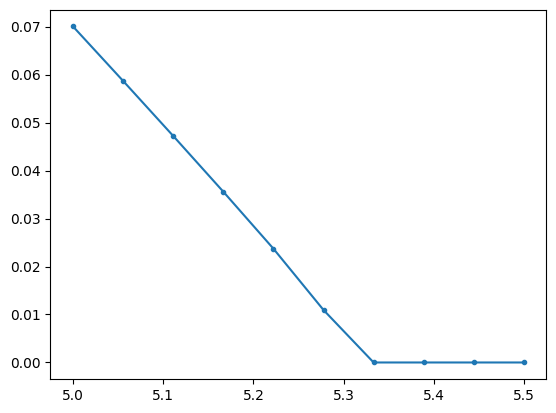

In [210]:
plt.plot(Us,out,'.-')

In [70]:
eps = np.linspace(0,22,num=500)
Z1 = []
Z2 = []
Z3 = []
Z4 = []
for eps_0 in eps:
        pars = {'beta':20.,
                'U':8,
                'alpha':1.,
                'eps_0':eps_0,
                'mixing':0.1,
                't_perp':None,
                'K_init':0.50,
                'iterations':1000,
                'M_trunc':20,
                }
        results = solver(pars)
        Z1.append(results['L'])
        Z2.append(results['n_spinon'])
        Z3.append(results['Q'])
        Z4.append(results['Lsq'])

  iter   1:  h=+0.000000   K=0.500000, K_new=0.083642
  iter   2:  h=+0.000000K=0.083642, K_new=0.008529  delta=7.51e-02
  iter   3:  h=+0.000000K=0.008529, K_new=0.000853  delta=7.68e-03
  iter   4:  h=+0.000000K=0.000853, K_new=0.000085  delta=7.68e-04
  iter   5:  h=+0.000000K=0.000085, K_new=0.000009  delta=7.68e-05
  iter   6:  h=+0.000000K=0.000009, K_new=0.000001  delta=7.68e-06
  iter   7:  h=+0.000000K=0.000001, K_new=0.000000  delta=7.68e-07
  iter   8:  h=+0.000000K=0.000000, K_new=0.000000  delta=7.68e-08
  iter   9:  h=+0.000000K=0.000000, K_new=0.000000  delta=7.68e-09
  iter  10:  h=+0.000000K=0.000000, K_new=0.000000  delta=7.68e-10
  iter  11:  h=+0.000000K=0.000000, K_new=0.000000  delta=7.68e-11
  iter   1:  h=+0.044083   K=0.500000, K_new=0.083653
  iter   2:  h=+0.044088K=0.083653, K_new=0.008530  delta=7.51e-02
  iter   3:  h=+0.044088K=0.008530, K_new=0.000853  delta=7.68e-03
  iter   4:  h=+0.044088K=0.000853, K_new=0.000085  delta=7.68e-04
  iter   5:  h=+0.044

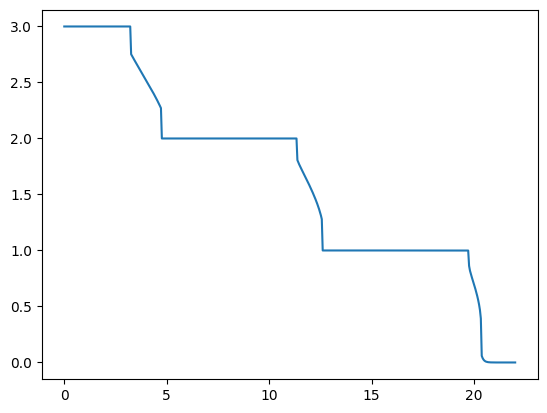

In [79]:
#plt.plot(eps,np.array(Z4) - np.array(Z1)**2,'.-') #charge variance
plt.plot(eps,np.array(Z1)+3,'-')

In [131]:
#let's check the nu=2 critical U:
eps_0 = 5
Us = np.linspace(0,7,num=1)
out = []
for U in Us:
    pars = {'beta':10.,
                'U':U,
                'alpha':1.,
                'eps_0':eps_0,
                'mixing':0.1,
                't_perp':None,
                'K_init':200,
                'iterations':1000,
                'M_trunc':10,
                }
    results = solver(pars)
    out.append(results['L'])

mu_eff = -4.443728571329188
  iter   1:  h=+0.687718   K=200.000000, K_new=20.000000
mu_eff = -5.081699961323257
  iter   2:  h=+0.068837K=20.000000, K_new=2.000000  delta=1.86e+01
mu_eff = -5.379025168660728
  iter   3:  h=+0.014139K=2.000000, K_new=0.200000  delta=1.85e+00
mu_eff = -11.020359168900184
  iter   4:  h=+0.009114K=0.200000, K_new=0.020000  delta=1.85e-01
mu_eff = -434.0781860654659
  iter   5:  h=+0.007942K=0.020000, K_new=0.002000  delta=1.92e-02
mu_eff = -33994.92289533778
  iter   6:  h=+0.007823K=0.002000, K_new=0.000200  delta=1.92e-03
mu_eff = -3373959.2106538545
  iter   7:  h=+0.007821K=0.000200, K_new=0.000020  delta=1.82e-04
mu_eff = -337369809.22520953
  iter   8:  h=+0.007821K=0.000020, K_new=0.000002  delta=1.80e-05
mu_eff = -33736954804.92761
  iter   9:  h=+0.007821K=0.000002, K_new=0.000000  delta=1.80e-06
mu_eff = -3373695454526.9663
  iter  10:  h=+0.007821K=0.000000, K_new=0.000000  delta=1.80e-07
mu_eff = -337369545412360.5
  iter  11:  h=+0.007821K=0

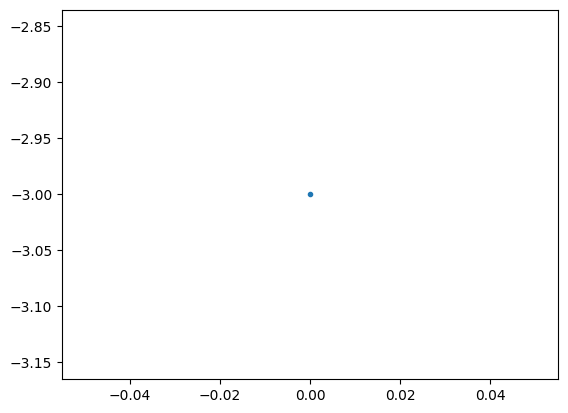

In [133]:
plt.plot(Us,np.array(out),'.')

---------------------------------------------------------------
From here on

------------------------------------------------
Step 0: Precompute the chemical potential table for a given DOS

In [214]:
def _T0_density_table(t_perp=None, density_grid=None, N_k=1000, N_e=2000):
    """
    Build T=0 noninteracting density table from _DOS_precomp.

    Returns a dict containing arrays for:
        density_grid : n values, per flavor, in [0, 1]
        mu0          : mu0(n), defined by int_{-inf}^{mu0} D(e) de = n
        epsbar       : int_{-inf}^{mu0(n)} D(e) e de

    Here n is per-flavor density.
    """

    if density_grid is None:
        density_grid = np.linspace(0.0, 1.0, 2001)

    density_grid = np.asarray(density_grid, dtype=float)

    if np.any(density_grid < 0.0) or np.any(density_grid > 1.0):
        raise ValueError("density_grid must lie in [0, 1].")

    eps, weights = slave_rotor_MF._DOS_precomp(t_perp=t_perp, N_k=N_k, N_e=N_e)

    eps = np.asarray(eps, dtype=float)
    weights = np.asarray(weights, dtype=float)

    # Sort by energy, just to be safe.
    order = np.argsort(eps)
    eps = eps[order]
    weights = weights[order]

    # Normalize weights defensively.
    wsum = np.sum(weights)
    if wsum <= 0:
        raise ValueError("DOS weights have non-positive total weight.")

    weights = weights / wsum

    # Cumulative density and cumulative kinetic energy.
    cdf = np.concatenate(([0.0], np.cumsum(weights)))
    ekin_cdf = np.concatenate(([0.0], np.cumsum(weights * eps)))

    # Energy value associated with each cumulative point.
    # At density 0, use bottom of the band.
    eps_cdf = np.concatenate(([eps[0]], eps))

    # Remove duplicate CDF entries, which can occur if some weights are zero.
    keep = np.concatenate(([True], np.diff(cdf) > 1e-14))
    cdf_u = cdf[keep]
    eps_cdf_u = eps_cdf[keep]
    ekin_cdf_u = ekin_cdf[keep]

    # Make sure the final point is exactly density 1.
    cdf_u[-1] = 1.0

    mu0 = np.interp(density_grid, cdf_u, eps_cdf_u)
    epsbar = np.interp(density_grid, cdf_u, ekin_cdf_u)

    return {
        "density_grid": density_grid,
        "mu0": mu0,
        "epsbar": epsbar,
        "eps": eps,
        "weights": weights,
        "cdf": cdf_u,
        "ekin_cdf": ekin_cdf_u,
        "t_perp": t_perp,
        "N_k": N_k,
        "N_e": N_e,
    }


def _lookup_T0_density_table(table, dens):
    """
    Look up mu0(dens), epsbar(dens) from a T=0 density table.

    dens is per-flavor density.
    """

    density_grid = table["density_grid"]

    if dens < density_grid[0] or dens > density_grid[-1]:
        raise ValueError(
            f"dens={dens} outside table range "
            f"[{density_grid[0]}, {density_grid[-1]}]"
        )

    mu0 = np.interp(dens, density_grid, table["mu0"])
    epsbar = np.interp(dens, density_grid, table["epsbar"])

    return mu0, epsbar

STep 1: Solve

In [237]:
def solver(pars):
    Ks = []
    hs = []
    epss = []
    Qs = []
    Zs = []
    I0s = []
    I1s = []
    K_raws = []
    mus_eff = []
    iter_info = []

    U = pars['U']
    alpha = pars['alpha']

    # typo-safe
    dens = pars.get('density', pars.get('denisty'))

    N = pars.get('N', 6.0)
    M_trunc = pars['M_trunc']
    t_perp = pars['t_perp']
    iterations = pars['iterations']
    beta = pars['beta']
    mixing = pars['mixing']

    tol = pars.get('tol', 1e-10)
    h_window = pars.get('h_window', 10.0)
    eps_window = pars.get('eps_window', 10.0)
    n_coarse = pars.get('n_coarse', 51)
    n_eigs = pars.get('n_eigs', 20)

    verbose = pars.get('verbose', 1)

    def is_beta_inf(beta_):
        if beta_ == 'inf':
            return True
        try:
            return np.isinf(beta_)
        except TypeError:
            return False

    beta_is_inf = is_beta_inf(beta)

    #####################
    # STEP 0  Precompute#
    #####################
    precomp = slave_rotor_atomic.build_rotor_precomp(U, alpha, M_trunc)
    dos = slave_rotor_MF._DOS_precomp(t_perp)

    # For strict T=0, do not solve the step-function density equation.
    # Instead read mu0(n) and epsbar(n) from the noninteracting density table.
    if beta_is_inf:
        if 't0_table' not in pars:
            raise ValueError(
                "For beta='inf', pass pars['t0_table']. "
                "Build it with _T0_density_table(...) before calling solver."
            )

        mu0_T0, epsbar_T0 = _lookup_T0_density_table(
            pars['t0_table'],
            dens
        )

        if verbose>1:
            print(
                f"T=0 density table: dens={dens:.12g}, "
                f"mu0={mu0_T0:+.12e}, epsbar={epsbar_T0:+.12e}"
            )
    else:
        mu0_T0 = None
        epsbar_T0 = None

    Ks.append(pars['K_init'])
    converged = False

    def pick_solution(sols, old=None):
        # NOTE fancier than just getting first solution. Check its fine.
        if verbose > 1:
            print(f'Solver found {len(sols)} solutions to SC equation..')
        if (verbose == 1) and (len(sols) != 1):
            print(f'Solver found {len(sols)} solutions to SC equation..')

        if len(sols) == 0:
            raise RuntimeError("solve_sc returned no solutions")

        if old is None:
            # pick smallest residual if no previous solution exists
            return min(sols, key=lambda s: abs(s.get('F', np.inf)))

        # continue the closest branch
        return min(sols, key=lambda s: abs(s['h'] - old))

    def spinon_integrals(Q, eps_, h_):
        # _spinon_integrals expects sqrt(Z), and Q = <cos theta> = sqrt(Z)
        return slave_rotor_MF._spinon_integrals(dos, Q, eps_, h_, beta)

    def solve_h_eps_for_K(K, h_old=None, eps_old=None):
        # 1) solve h from fixed-density rotor constraint
        def eval_L_rot(h_):
            Out = slave_rotor_atomic.eval_rotor_obs(
                precomp, h_, K, beta,
                obs_indices=(0,),
                n_eigs=n_eigs
            )
            L_AVG = Out['obs'][0]
            return L_AVG - N * (dens - 0.5)

        def rhs_zero(x):
            return 0.0

        sols_h = slave_rotor_atomic.solve_sc(
            eval_L_rot,
            rhs_zero,
            beta,
            h_window=h_window,
            n_coarse=n_coarse,
            tol=tol,
            verbose=False
        )

        sol_h = pick_solution(sols_h, h_old)
        h = sol_h['h']

        # 2) rotor observables at this h,K
        Out = slave_rotor_atomic.eval_rotor_obs(
            precomp, h, K, beta,
            obs_indices=(0, 1),
            n_eigs=n_eigs
        )

        L_AVG = Out['obs'][0]
        L2_AVG = Out['obs'][1]
        Q = Out['Q']
        Z = Q**2

        # 3) epsilon_0 and spinon integrals
        if beta_is_inf:
            # T=0 fixed-density equations:
            #
            #     eps = h - Z*mu0(n)
            #     I0 = n
            #     I1 = epsbar(n)
            #
            # No numerical density solve here.
            eps = h - Z * mu0_T0
            I0 = dens
            I1 = epsbar_T0

            sol_eps = {
                'h': eps,
                'method': 'T0 density table',
                'mu0': mu0_T0,
                'epsbar': epsbar_T0,
                'F': 0.0,
            }
            sols_eps = [sol_eps]

        else:
            # finite-T fixed-density route:
            # solve epsilon_0 from
            #
            #     int d eps D(eps) nF(Z eps + epsilon_0 - h) = dens
            #
            def eval_dens(eps_):
                I0_tmp, _ = spinon_integrals(Q, eps_, h)
                return I0_tmp - dens

            sols_eps = slave_rotor_atomic.solve_sc(
                eval_dens,
                rhs_zero,
                beta,
                h_window=eps_window,
                n_coarse=n_coarse,
                tol=tol,
                verbose=False
            )

            sol_eps = pick_solution(sols_eps, eps_old)
            eps = sol_eps['h']   # solve_sc always uses key 'h'

            I0, I1 = spinon_integrals(Q, eps, h)

        # 4) K update
        K_raw = 2.0 * N * Q * I1

        # At T=0 this is literally the effective Fermi level.
        # At finite T it is still the center of the Fermi function, but the
        # occupation is thermally broadened.
        if abs(Z) > 1e-14:
            mu_eff = (h - eps) / Z
        else:
            mu_eff = np.nan

        info = {
            'K_in': K,
            'h': h,
            'eps': eps,
            'Q': Q,
            'Z': Z,
            'L': L_AVG,
            'Lsq': L2_AVG,
            'I0': I0,
            'I1': I1,
            'mu_eff': mu_eff,
            'K_raw': K_raw,
            'res_h': L_AVG - N * (dens - 0.5),
            'res_density': I0 - dens,
            'sol_h': sol_h,
            'sol_eps': sol_eps,
            'all_sols_h': sols_h,
            'all_sols_eps': sols_eps,
            'beta_is_inf': beta_is_inf,
            'mu0_T0': mu0_T0,
            'epsbar_T0': epsbar_T0,
        }

        return info

    h_old = None
    eps_old = None

    for it in range(iterations):
        K = Ks[-1]

        # 1) Solve for new h, epsilon_0, K_raw
        info = solve_h_eps_for_K(K, h_old=h_old, eps_old=eps_old)

        h = info['h']
        eps = info['eps']
        Q = info['Q']
        Z = info['Z']
        I0 = info['I0']
        I1 = info['I1']
        K_raw = info['K_raw']

        K_new = mixing * K + (1.0 - mixing) * K_raw

        info['iteration'] = it + 1
        info['K_new'] = K_new
        info['delta_K'] = abs(K_new - K)

        if it == 0:
            delta = np.inf
        else:
            delta = (
                abs(K_new - K)
                + abs(h - hs[-1])
                + abs(eps - epss[-1])
            )

        info['delta'] = delta

        hs.append(h)
        epss.append(eps)
        Qs.append(Q)
        Zs.append(Z)
        I0s.append(I0)
        I1s.append(I1)
        K_raws.append(K_raw)
        mus_eff.append(info['mu_eff'])
        iter_info.append(info)

        Ks.append(K_new)

        print(
            f"  iter {it+1:3d}: "
            f"h={h:+.8e} "
            f"eps={eps:+.8e} "
            f"K={K:+.8e} "
            f"K_raw={K_raw:+.8e} "
            f"K_new={K_new:+.8e} "
            f"Q={Q:+.8e} "
            f"I0={I0:+.8e} "
            f"I1={I1:+.8e} "
            f"mu_eff={info['mu_eff']:+.8e} "
            f"delta={delta:.3e}"
        )

        if delta < tol:
            converged = True
            break

        h_old = h
        eps_old = eps

    # Final consistency solve:
    # Ks[-1] is the final mixed K, so recompute h and eps for this K.
    K_con = Ks[-1]

    final_info = solve_h_eps_for_K(
        K_con,
        h_old=hs[-1] if len(hs) else None,
        eps_old=epss[-1] if len(epss) else None
    )

    h_con = final_info['h']
    eps_con = final_info['eps']
    costh = final_info['Q']
    Z_con = final_info['Z']

    results = {
        'h': h_con,
        'eps_0': eps_con,
        'Q': costh,
        'Z': Z_con,
        'K': K_con,
        'K_raw_final': final_info['K_raw'],
        'K_residual_final': K_con - final_info['K_raw'],

        'L': final_info['L'],
        'Lsq': final_info['Lsq'],
        'n_spinon': final_info['I0'],
        'I1': final_info['I1'],
        'mu_eff': final_info['mu_eff'],

        'res_h': final_info['res_h'],
        'res_density': final_info['res_density'],

        'converged': converged,
        'iterations': it + 1,

        'beta_is_inf': beta_is_inf,
        'mu0_T0': mu0_T0,
        'epsbar_T0': epsbar_T0,

        'hs': hs,
        'epss': epss,
        'Ks': Ks,
        'Qs': Qs,
        'Zs': Zs,
        'I0s': I0s,
        'I1s': I1s,
        'K_raws': K_raws,
        'mus_eff': mus_eff,

        'iter_info': iter_info,
        'final_info': final_info,
    }

    return results

In [241]:
pars = {'beta':'inf',
        'U':10.,
        'alpha':1.,
        'density':1./6,
        'mixing':0.5,
        't_perp':None,
        'K_init':2,
        'iterations':2000,
        'M_trunc':8,
        'N':6,
        'tol':1e-8,
        'h_window':20.,
        'eps_window':20.,
        'n_coarse':51,
        'n_eigs':20,
        'verbose':1
        }
t0_table = _T0_density_table(
    t_perp=pars["t_perp"],
    density_grid=np.linspace(1./6,3./6,num=3,endpoint=True),
    N_k=1000,
    N_e=4000,
)
pars["t0_table"] = t0_table

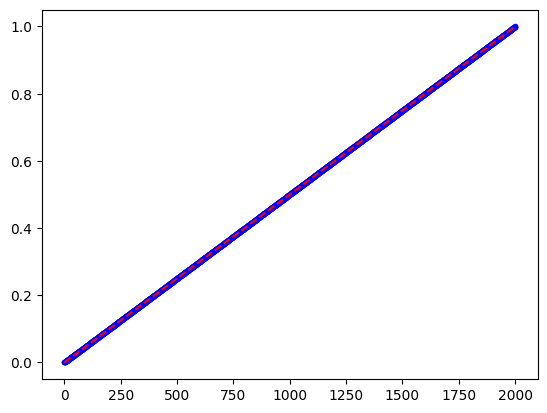

In [ ]:
n = t0_table['density_grid']
mu = t0_table['mu0']
plt.plot(n,'.',c='blue')
plt.plot(0.5*mu+0.5,'--',c='red',alpha=1,label='')

  iter   1: h=+5.20000000e+00 eps=+5.29858855e+00 K=+2.00000000e+00 K_raw=+1.44988671e+00 K_new=+1.72494336e+00 Q=-5.43571625e-01 I0=+3.33333333e-01 I1=-2.22277778e-01 mu_eff=-3.33666750e-01 delta=inf
  iter   2: h=+5.20000000e+00 eps=+5.28387041e+00 K=+1.72494336e+00 K_raw=+1.33728885e+00 K_new=+1.53111610e+00 Q=-5.01357978e-01 I0=+3.33333333e-01 I1=-2.22277778e-01 mu_eff=-3.33666750e-01 delta=2.085e-01
  iter   3: h=+5.20000000e+00 eps=+5.27256778e+00 K=+1.53111610e+00 K_raw=+1.24392084e+00 K_new=+1.38751847e+00 Q=-4.66353725e-01 I0=+3.33333333e-01 I1=-2.22277778e-01 mu_eff=-3.33666750e-01 delta=1.549e-01
  iter   4: h=+5.20000000e+00 eps=+5.26378190e+00 K=+1.38751847e+00 K_raw=+1.16619066e+00 K_new=+1.27685456e+00 Q=-4.37212193e-01 I0=+3.33333333e-01 I1=-2.22277778e-01 mu_eff=-3.33666750e-01 delta=1.194e-01
  iter   5: h=+5.20000000e+00 eps=+5.25683774e+00 K=+1.27685456e+00 K_raw=+1.10087811e+00 K_new=+1.18886633e+00 Q=-4.12726108e-01 I0=+3.33333333e-01 I1=-2.22277778e-01 mu_eff=-3.

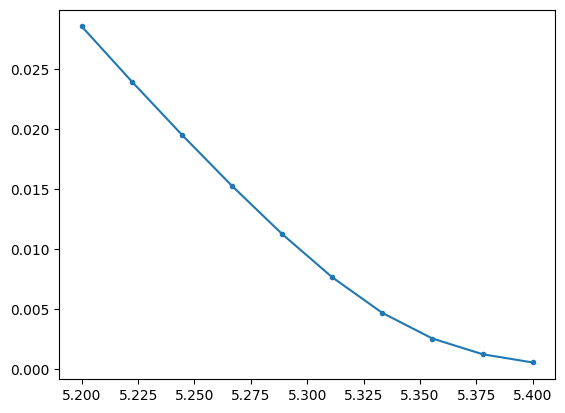

In [257]:
pars = {'beta':'inf',
        'U':10.,
        'alpha':1.,
        'density':2./6,
        'mixing':0.5,
        't_perp':None,
        'K_init':2,
        'iterations':400,
        'M_trunc':8,
        'N':6,
        'tol':1e-8,
        'h_window':20.,
        'eps_window':20.,
        'n_coarse':51,
        'n_eigs':20,
        'verbose':1
        }
t0_table = _T0_density_table(
    t_perp=pars["t_perp"],
    density_grid=np.linspace(1./6,3./6,num=3,endpoint=True),
    N_k=1000,
    N_e=4000,
)
pars["t0_table"] = t0_table
Us = np.linspace(5.2,5.4,num=10)
out = []
for U in Us:
        pars['U'] = U
        results = solver(pars)
        out.append(results['Z'])
plt.plot(Us,out,'.-')    


(-0.04109954065653039, 1.01)

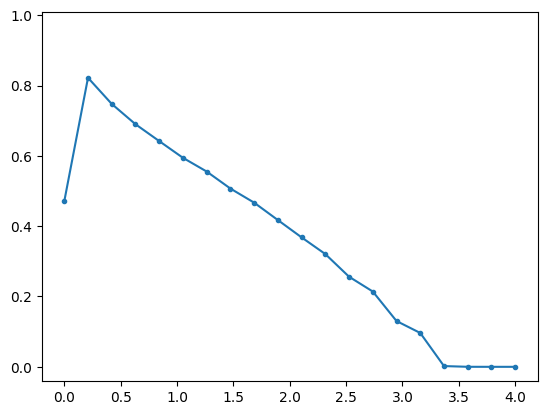

In [251]:
plt.plot(Us,out,'.-') 
plt.ylim([None,1.01])

In [271]:
ns = np.linspace(0.5,1,num=100,endpoint=True)
pars = {'beta':10.,
        'U':6.5,
        'alpha':1.,
        'density':2./6,
        'mixing':0.5,
        't_perp':None,
        'K_init':2,
        'iterations':400,
        'M_trunc':8,
        'N':6,
        'tol':1e-8,
        'h_window':20.,
        'eps_window':20.,
        'n_coarse':51,
        'n_eigs':20,
        'verbose':1
        }
t0_table = _T0_density_table(
    t_perp=pars["t_perp"],
    density_grid=ns,
    N_k=1000,
    N_e=4000,
)
pars["t0_table"] = t0_table
Y1 = []
Y2 = []
for n in ns:
        pars['density'] = n
        results = solver(pars)
        Y1.append(results['eps_0'])
        Y2.append(results['n_spinon'])   

  iter   1: h=+0.00000000e+00 eps=+0.00000000e+00 K=+2.00000000e+00 K_raw=+8.89204651e-01 K_new=+1.44460233e+00 Q=-4.79338863e-01 I0=+5.00000000e-01 I1=-1.54588733e-01 mu_eff=+0.00000000e+00 delta=inf
  iter   2: h=+0.00000000e+00 eps=+0.00000000e+00 K=+1.44460233e+00 K_raw=+5.12498466e-01 K_new=+9.78550395e-01 Q=-3.83769110e-01 I0=+5.00000000e-01 I1=-1.11286199e-01 mu_eff=+0.00000000e+00 delta=4.661e-01
  iter   3: h=+0.00000000e+00 eps=+0.00000000e+00 K=+9.78550395e-01 K_raw=+2.12898401e-01 K_new=+5.95724398e-01 Q=-2.79833882e-01 I0=+5.00000000e-01 I1=-6.34002333e-02 mu_eff=+0.00000000e+00 delta=3.828e-01
  iter   4: h=+0.00000000e+00 eps=+0.00000000e+00 K=+5.95724398e-01 K_raw=+5.63123101e-02 K_new=+3.26018354e-01 Q=-1.78148736e-01 I0=+5.00000000e-01 I1=-2.63414303e-02 mu_eff=+0.00000000e+00 delta=2.697e-01
  iter   5: h=+0.00000000e+00 eps=+0.00000000e+00 K=+3.26018354e-01 K_raw=+9.83860857e-03 K_new=+1.67928481e-01 Q=-9.94421752e-02 I0=+5.00000000e-01 I1=-8.24483220e-03 mu_eff=+0.

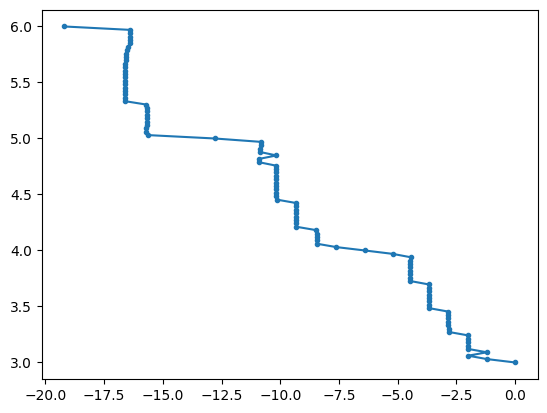

In [270]:
plt.plot(Y1,6*ns,'.-')